In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from google.colab import files

print("Libraries imported successfully!")

Libraries imported successfully!


Saving fruits.jpg to fruits.jpg
Image loaded successfully: fruits.jpg


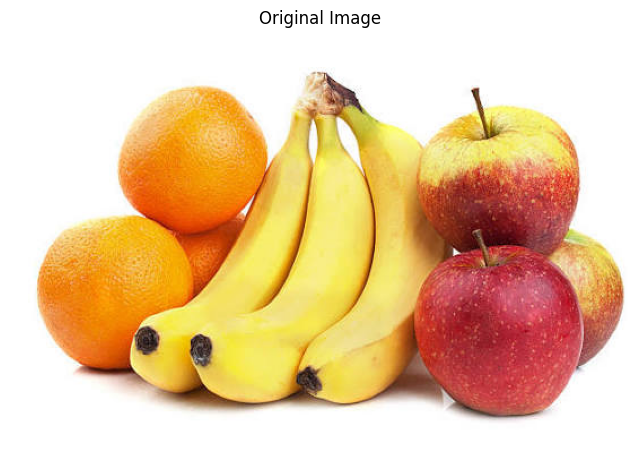

In [ ]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

if img is None:
    print("Error: Image could not be loaded.")
else:
    print("Image loaded successfully:", filename)

    # Convert BGR to RGB for displaying with Matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

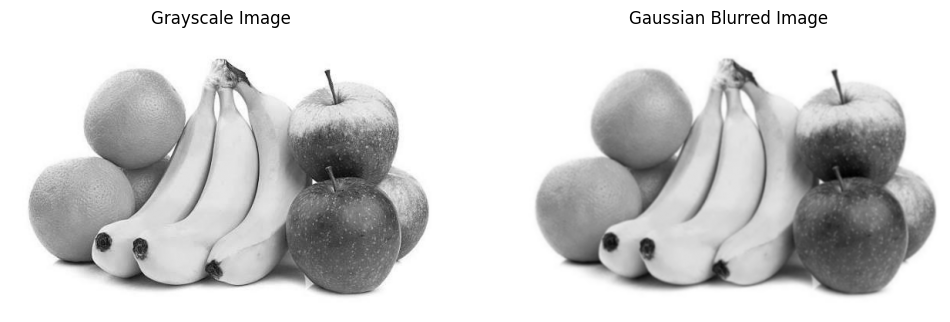

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred, cmap='gray')
plt.title("Gaussian Blurred Image")
plt.axis("off")

plt.show()

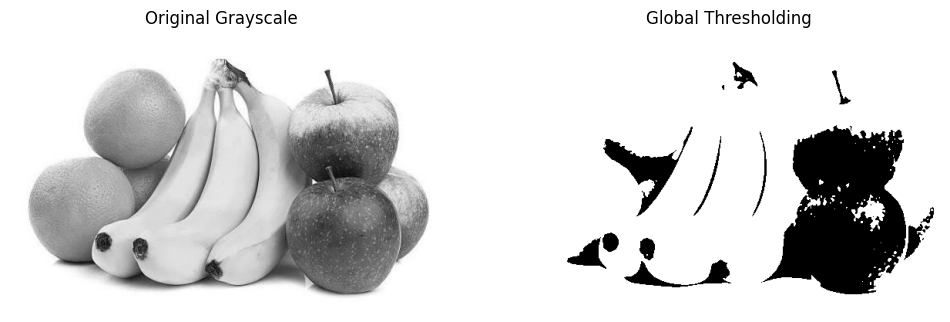

Threshold value: 127.0


In [ ]:
threshold_value = 127

ret, global_thresh = cv2.threshold(
    blurred,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(global_thresh, cmap='gray')
plt.title("Global Thresholding")
plt.axis("off")

plt.show()

print("Threshold value:", ret)

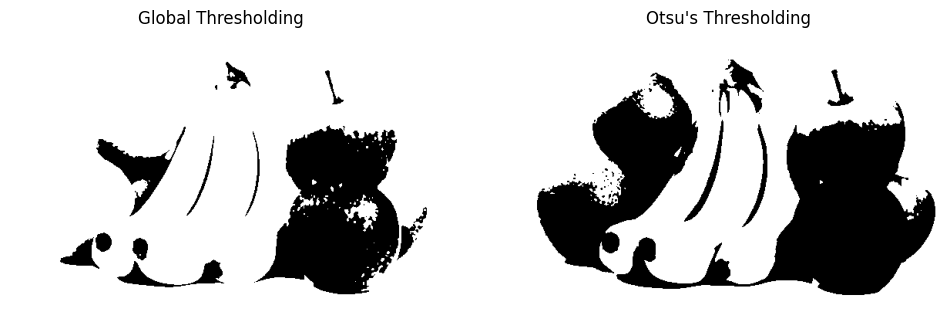

Automatically selected Otsu threshold: 179.0


In [ ]:
otsu_value, otsu_thresh = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(global_thresh, cmap='gray')
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(otsu_thresh, cmap='gray')
plt.title("Otsu's Thresholding")
plt.axis("off")

plt.show()

print("Automatically selected Otsu threshold:", otsu_value)

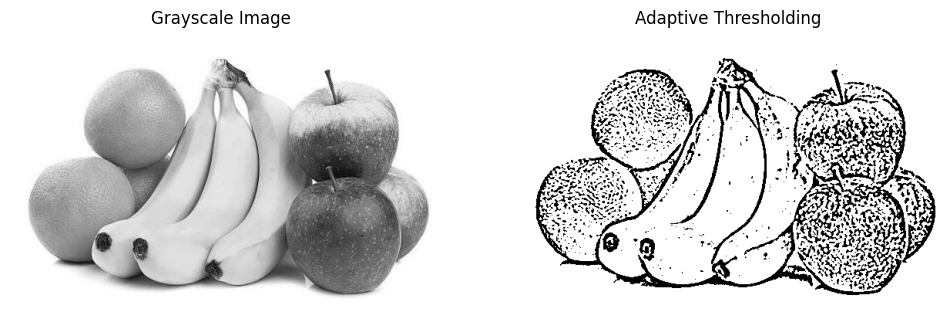

In [ ]:
adaptive_thresh = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(adaptive_thresh, cmap='gray')
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.show()

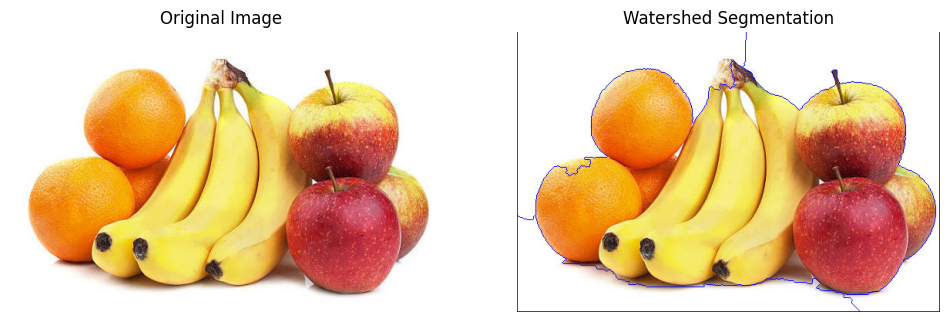

In [ ]:
# Convert threshold image to binary
binary = otsu_thresh

# Noise removal using morphological opening
kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

# Determine sure background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Distance transform
dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

# Determine sure foreground
_, sure_fg = cv2.threshold(
    dist_transform,
    0.5 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# Unknown region
unknown = cv2.subtract(
    sure_bg,
    sure_fg
)

# Marker labeling
num_labels, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

# Apply watershed
watershed_img = img.copy()

markers = cv2.watershed(
    watershed_img,
    markers
)

# Mark boundaries in red
watershed_img[markers == -1] = [255, 0, 0]

watershed_rgb = cv2.cvtColor(
    watershed_img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(watershed_rgb)
plt.title("Watershed Segmentation")
plt.axis("off")

plt.show()

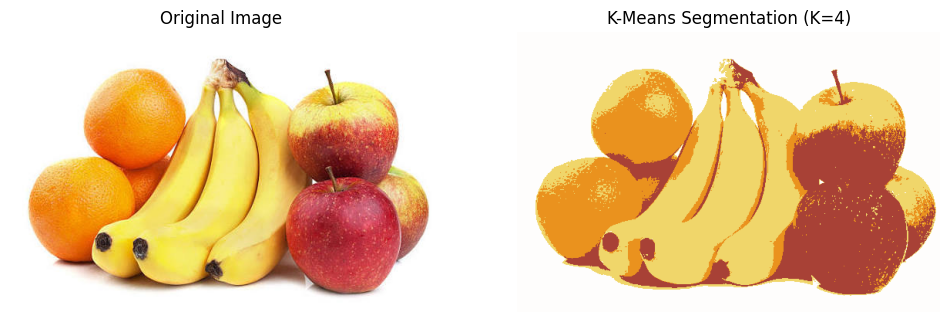

In [ ]:
# Convert image from BGR to RGB
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Reshape image into a list of pixels
pixel_data = image_rgb.reshape((-1, 3))

# Convert to float32
pixel_data = np.float32(pixel_data)

# Number of clusters
K = 4

# Create K-Means model
kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

# Train model
kmeans.fit(pixel_data)

# Get cluster centers
centers = np.uint8(kmeans.cluster_centers_)

# Get labels
labels = kmeans.labels_

# Replace each pixel with its cluster center
segmented_data = centers[labels]

# Reshape back to original image
segmented_image = segmented_data.reshape(image_rgb.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title("K-Means Segmentation (K=4)")
plt.axis("off")

plt.show()

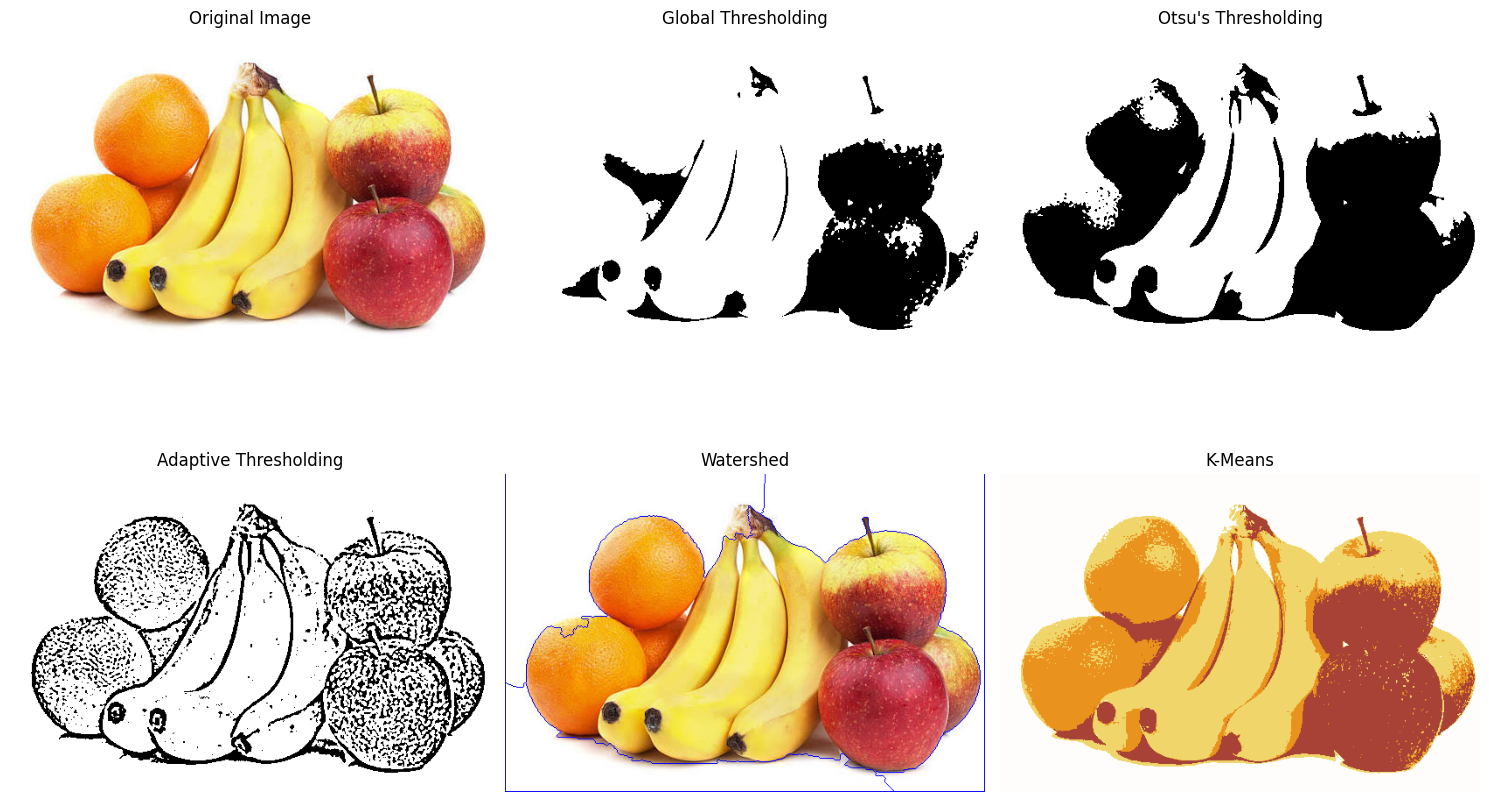

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(otsu_thresh, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(adaptive_thresh, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(watershed_rgb)
plt.title("Watershed")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(segmented_image)
plt.title("K-Means")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import time

# Global Thresholding
start = time.time()
cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)
global_time = time.time() - start

# Otsu
start = time.time()
cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
otsu_time = time.time() - start

# Adaptive Thresholding
start = time.time()
cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)
adaptive_time = time.time() - start

print("Computational Time Comparison")
print("--------------------------------")
print(f"Global Thresholding   : {global_time:.6f} seconds")
print(f"Otsu Thresholding     : {otsu_time:.6f} seconds")
print(f"Adaptive Thresholding : {adaptive_time:.6f} seconds")

Computational Time Comparison
--------------------------------
Global Thresholding   : 0.000593 seconds
Otsu Thresholding     : 0.000476 seconds
Adaptive Thresholding : 0.002031 seconds


## Comparison of Image Segmentation Techniques

| Technique | Type | Main Advantage | Limitation |
|---|---|---|---|
| Global Thresholding | Intensity-based | Simple and fast | Sensitive to illumination |
| Otsu's Thresholding | Automatic threshold | Automatically selects threshold | Works best with suitable histogram |
| Adaptive Thresholding | Local threshold | Handles uneven illumination | More computationally expensive |
| Watershed | Region/Boundary-based | Separates touching objects | Can cause over-segmentation |
| K-Means | Clustering-based | Useful for color segmentation | Requires choosing K |


OBSERVATIONS:

1. Global Thresholding successfully separates foreground and background
   when illumination is relatively uniform.

2. Otsu's Thresholding automatically determines a suitable threshold
   based on the image histogram.

3. Adaptive Thresholding performs better when illumination varies
   across different regions of the image.

4. Watershed Segmentation can separate touching or overlapping objects
   by using distance-based markers and boundaries.

5. K-Means Clustering divides image pixels into different color-based
   clusters and is useful for color segmentation.

6. No single segmentation technique is best for every image.
   The appropriate method depends on image characteristics.



CONCLUSION:

In this experiment, different image segmentation techniques were
implemented using Python, OpenCV, NumPy, Matplotlib and Scikit-learn.

Global Thresholding, Otsu's Thresholding, Adaptive Thresholding,
Watershed Segmentation and K-Means Clustering were applied and their
outputs were compared.

Threshold-based techniques are simple and efficient for suitable
images, while Watershed is useful for separating touching objects.
K-Means is particularly useful for color-based segmentation.

Therefore, the selection of a segmentation technique depends on
factors such as illumination, object boundaries, color information,
background complexity and the requirements of the computer vision task.


##Q1. What is image segmentation? Why is it fundamental in computer vision?

Answer:

Image segmentation is the process of dividing an image into meaningful regions or objects based on characteristics such as intensity, color, texture, or boundaries. It is fundamental because it helps isolate regions of interest and simplifies further computer vision tasks such as object detection, recognition, medical diagnosis, and autonomous navigation.

## Q2. Differentiate between Image Segmentation and Image Classification

| Image Segmentation | Image Classification |
|---|---|
| Divides an image into meaningful regions or objects. | Assigns a class or category to an image. |
| Works at the pixel or region level. | Usually works at the image level. |
| Identifies where an object is present in the image. | Identifies what the object or image represents. |
| Produces a segmented image or mask. | Produces a class label as the output. |
| Used for object localization and identifying regions of interest. | Used for recognizing and categorizing images or objects. |

##Q3. Explain Global, Otsu's and Adaptive Thresholding.

Global Thresholding:

Uses one fixed threshold value for the entire image. Pixels above the threshold are assigned one value and pixels below it another.

Otsu's Thresholding:


Automatically determines an optimal threshold by analyzing the image histogram and minimizing intra-class variance.

Adaptive Thresholding:

Calculates different threshold values for different local regions of an image. It is useful when illumination is not uniform.

##Q4. What is the Watershed Algorithm?

Watershed is a segmentation algorithm that treats an image like a topographic surface. It uses markers and boundaries to divide different regions.

It is particularly useful for separating touching or overlapping objects, because it can identify boundaries between connected objects.

##Q5. How is K-Means applied to image segmentation?

In K-Means image segmentation, every pixel is represented using its color values. K-Means groups pixels into K clusters based on similarity.

The center of each cluster represents a dominant color. Each pixel is then replaced by the color of its cluster, producing a segmented image.

## Q6. Compare Threshold-Based Segmentation and Clustering-Based Segmentation Techniques

| Threshold-Based Segmentation | Clustering-Based Segmentation |
|---|---|
| Uses threshold values to divide an image into regions. | Groups similar pixels into different clusters. |
| Usually simpler to implement. | More flexible for images with multiple regions. |
| Works well when foreground and background have clear intensity differences. | Works well when pixels have similar color or feature characteristics. |
| Generally faster and computationally less expensive. | Can require more computational resources. |
| Examples include Global Thresholding, Otsu's Thresholding, and Adaptive Thresholding. | K-Means Clustering is a common example. |

##Q7. What challenges occur with complex backgrounds or varying illumination?

Major challenges include:

Similar foreground and background colors
Uneven lighting
Shadows
Image noise
Low contrast
Complex textures
Overlapping objects
Poor object boundaries

These conditions can make it difficult to correctly separate foreground objects from the background.

##Q8. Mention five real-world applications.

Five applications are:

Medical image analysis
Autonomous vehicles
Object detection
Satellite image analysis
Industrial inspection

##Q9. How does segmentation improve object detection and recognition?

Segmentation separates the important object or region from the background. This reduces irrelevant information and allows the detection or recognition system to focus on the region of interest.

As a result, segmentation can improve object localization, boundary identification, feature extraction, and overall recognition performance.

## Q10. Compare Traditional Image Segmentation Techniques with Deep Learning-Based Segmentation Methods such as U-Net and Mask R-CNN

| Traditional Segmentation Techniques | Deep Learning-Based Segmentation |
|---|---|
| Use manually designed rules and algorithms. | Use deep neural networks to learn features automatically. |
| Examples include Thresholding, Otsu's Thresholding, Adaptive Thresholding, Watershed, and K-Means. | Examples include U-Net and Mask R-CNN. |
| Usually require less computational power. | Generally require higher computational resources. |
| Can be simple and fast for suitable images. | Can handle complex image patterns more effectively. |
| Performance depends strongly on image intensity, color, boundaries, and illumination. | Performance depends on the quality and quantity of training data. |
| Easier to implement for simple segmentation tasks. | More complex to train and implement. |
| Suitable for images with relatively simple and predictable characteristics. | Suitable for complex real-world segmentation problems. |